# Heatwave Risk Projection — Kazakhstan (Oblast Level)
**CLIMAAX Heatwave Risk Projection workflow adapted for Kazakhstan**

- Based on the CLIMAAX [Handbook](https://handbook.climaax.eu/) HEATWAVES risk projection workflow
- Combines **projected change in heatwave occurrence** (hazard) with
  **vulnerable population density** (vulnerability) at oblast level
- ISIMIP3b data is downloaded directly in this notebook for all of Kazakhstan


---
## Data Substitutions

| Original (CLIMAAX EU) | Kazakhstan replacement |
|---|---|
| EuroHEAT CDS data (`sis-heat-and-cold-spells`, EU-only) | ISIMIP3b bias-adjusted global data, downloaded directly |
| RCP4.5 / RCP8.5 scenarios | SSP1-2.6 (ssp126) / SSP3-7.0 (ssp370) |
| Historical baseline 1986–2015 | Historical baseline 1985–2014 (ISIMIP3b historical run ends 2014) |
| Near future 2016–2045 | Near future 2015–2044 |
| Far future 2046–2075 | Far future 2045–2074 |
| GADM shapefile + NAME_1/NAME_2 fields | Kazakhstan OSM shapefile, `oblast_en` field |
| Cataluña subregion logic | Kazakhstan oblast selection |
| 12×12 km EURO-CORDEX grid | ISIMIP3b 0.5° (~55 km) — zonal stats aggregated to oblast |
| WorldPop age-stratified population | Same — Kazakhstan files (`kaz_*`) ✓ |

## Interpretation note

Risk levels reflect **relative differences between Kazakhstan oblasts only**.
A “Very High” rating means highest risk within Kazakhstan — not globally.
The 0.5° grid resolution means results are most meaningful at oblast scale;
intra-oblast variation is not captured.


## Step 0: Configuration


In [ ]:
from pathlib import Path

HIST_START = '1985-01-01';  HIST_END = '2014-12-31'
NEAR_START = '2015-01-01';  NEAR_END = '2044-12-31'
FAR_START  = '2045-01-01';  FAR_END  = '2074-12-31'

MODEL_NAMES    = ['gfdl-esm4']
MODEL_ENSEMBLE = {'gfdl-esm4': 'r1i1p1f1'}
SCENARIOS      = ['historical', 'ssp126', 'ssp370']

HWI_THRESH_TASMAX = '35 degC'
HWI_WINDOW        = 3

SELECTED_OBLASTS = None

BASE_URL  = (
    "https://files.isimip.org/ISIMIP3b/InputData/"
    "climate/atmosphere/bias-adjusted/global/daily"
)
CLIP_BBOX = [46.0, 40.0, 88.0, 56.0]

DECADES = {
    'historical': [
        (1971, 1980), (1981, 1990), (1991, 2000),
        (2001, 2010), (2011, 2014),
    ],
    'ssp126': [
        (2015, 2020), (2021, 2030), (2031, 2040), (2041, 2050),
        (2051, 2060), (2061, 2070), (2071, 2080), (2081, 2090),
        (2091, 2100),
    ],
    'ssp370': [
        (2015, 2020), (2021, 2030), (2031, 2040), (2041, 2050),
        (2051, 2060), (2061, 2070), (2071, 2080), (2081, 2090),
        (2091, 2100),
    ],
}

WORKFLOW_FOLDER = Path('Heatwave_risk_projection_KZ')
DATA_DIR        = WORKFLOW_FOLDER / 'data'
POP_DIR         = DATA_DIR / 'population'
RESULTS_DIR     = WORKFLOW_FOLDER / 'results'

SHAPEFILE_PATH = Path(
    r"C:\Users\dauzo\Models\crabook-kazakhstan\crabook"
    r"\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp"
) 
OBLAST_FIELD = "oblast_en"

## Step 1: Imports and Setup


In [2]:
import warnings
import requests
import numpy as np
import xarray as xr
import xclim
import geopandas as gpd
import rasterio
import rioxarray
import rasterstats
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

warnings.filterwarnings('ignore')

for d in [WORKFLOW_FOLDER, DATA_DIR, POP_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Results dir : {RESULTS_DIR.resolve()}")

Results dir : C:\Users\dauzo\Models\crabook-kazakhstan\crabook\notebooks\workflows\HEATWAVES\01_Urban_heatwaves\Heatwave_risk_projection_KZ\results


## Step 2: Load Kazakhstan Oblast Boundaries


Using all 20 oblasts


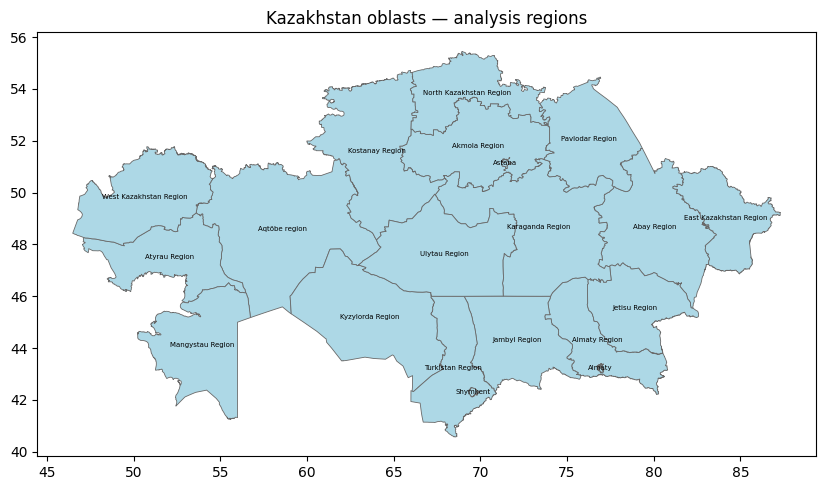

Bounding box: [46.4932179 40.5686902 87.3156336 55.4421701]


In [ ]:
kaz_gdf = gpd.read_file(SHAPEFILE_PATH)

if SELECTED_OBLASTS is not None:
    gdf = kaz_gdf[kaz_gdf[OBLAST_FIELD].isin(SELECTED_OBLASTS)].copy()
    print(f"Using {len(gdf)} selected oblasts: {SELECTED_OBLASTS}")
else:
    gdf = kaz_gdf.dissolve(by=OBLAST_FIELD).reset_index()
    print(f"Using all {len(gdf)} oblasts")

gdf = gdf.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(10, 5))
gdf.plot(ax=ax, facecolor='lightblue', edgecolor='dimgray', linewidth=0.6)
for _, row in gdf.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(cx, cy, row[OBLAST_FIELD], fontsize=5, ha='center', va='center')
ax.set_title("Kazakhstan oblasts — analysis regions", size=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'oblasts_map.png', dpi=150, bbox_inches='tight')
plt.show()

bbox = gdf.total_bounds   
print(f"Bounding box: {bbox}")

## Step 3: Download ISIMIP3b Tasmax and Compute HWI

Downloads `tasmax` for all configured models × 3 scenarios × decade chunks,
clipped to the full Kazakhstan extent. Each global file is clipped immediately
and the raw download is deleted. Already-clipped files are skipped.
HWI is then computed and cached per model × scenario.


In [ ]:
from tqdm.auto import tqdm
import time

def build_url(model, scenario, var, start, end):
    ensemble  = MODEL_ENSEMBLE[model]
    model_dir = model.upper()
    fname = (
        f"{model}_{ensemble}_w5e5_{scenario}_{var}"
        f"_global_daily_{start}_{end}.nc"
    )
    return f"{BASE_URL}/{scenario}/{model_dir}/{fname}"


def download_chunk(model, scenario, var, start, end):
    clip_path = DATA_DIR / f"{model}_{scenario}_{var}_{start}_{end}_clip.nc"
    if clip_path.exists():
        tqdm.write(f"    Cached: {clip_path.name}")
        return True

    url      = build_url(model, scenario, var, start, end)
    tmp_path = DATA_DIR / f"_tmp_{model}_{scenario}_{var}_{start}_{end}.nc"

    try:
        with requests.get(url, stream=True, timeout=300) as r:
            r.raise_for_status()
            total = int(r.headers.get('Content-Length', 0)) or None
            with (
                open(tmp_path, 'wb') as fout,
                tqdm(total=total, unit='B', unit_scale=True,
                     desc=f'    ↓ {url.split("/")[-1]}',
                     leave=False, dynamic_ncols=True, position=1) as pbar
            ):
                for chunk in r.iter_content(chunk_size=1 << 20):
                    fout.write(chunk)
                    pbar.update(len(chunk))

        with xr.open_dataset(tmp_path) as ds:
            ds_clip = ds.sortby('lat').sel(
                lat=slice(CLIP_BBOX[1], CLIP_BBOX[3]),
                lon=slice(CLIP_BBOX[0], CLIP_BBOX[2]),
            )
            ds_clip.load().to_netcdf(clip_path)

        for _ in range(5):
            try:
                tmp_path.unlink(); break
            except PermissionError:
                time.sleep(1)

        tqdm.write(f"    ✓ Saved: {clip_path.name}")
        return True

    except Exception as exc:
        tqdm.write(f"    ✗ FAILED: {exc}")
        if tmp_path.exists(): tmp_path.unlink()
        return False


combos = [(m, s, 'tasmax') for m in MODEL_NAMES for s in SCENARIOS]

download_results = {}
with tqdm(combos, desc='Overall progress', unit='combo') as outer:  
    for model, scenario, var in outer:
        key = f'{model}/{scenario}/{var}'
        outer.set_postfix_str(key, refresh=True)
        results = [
            download_chunk(model, scenario, var, s, e)
            for s, e in DECADES[scenario]
        ]
        download_results[key] = results

print('\nDownload summary:')
for key, chunks in download_results.items():
    n_ok = sum(chunks)
    status = '✓ OK' if n_ok == len(chunks) else f'✗ {len(chunks)-n_ok} failed'
    print(f'  {key:<48s}  {n_ok}/{len(chunks)}  {status}')

Overall progress:   0%|          | 0/3 [00:00<?, ?combo/s]

    ↓ gfdl-esm4_r1i1p1f1_w5e5_historical_tasmax_global_daily_1971_1980.nc:   0%|          | 0.00/2.07G [00:00<…

    ✓ Saved: gfdl-esm4_historical_tasmax_1971_1980_clip.nc


    ↓ gfdl-esm4_r1i1p1f1_w5e5_historical_tasmax_global_daily_1981_1990.nc:   0%|          | 0.00/2.07G [00:00<…

    ✓ Saved: gfdl-esm4_historical_tasmax_1981_1990_clip.nc


...

    ✓ Saved: gfdl-esm4_ssp370_tasmax_2071_2080_clip.nc


    ↓ gfdl-esm4_r1i1p1f1_w5e5_ssp370_tasmax_global_daily_2081_2090.nc:   0%|          | 0.00/2.06G [00:00<?, ?…

    ✓ Saved: gfdl-esm4_ssp370_tasmax_2081_2090_clip.nc


    ↓ gfdl-esm4_r1i1p1f1_w5e5_ssp370_tasmax_global_daily_2091_2100.nc:   0%|          | 0.00/2.06G [00:00<?, ?…

    ✓ Saved: gfdl-esm4_ssp370_tasmax_2091_2100_clip.nc

Download summary:
  gfdl-esm4/historical/tasmax                       5/5  ✓ OK
  gfdl-esm4/ssp126/tasmax                           9/9  ✓ OK
  gfdl-esm4/ssp370/tasmax                           9/9  ✓ OK


In [ ]:
def load_model_var(model, scenario, var):
    das = []
    for start, end in DECADES[scenario]:
        path = DATA_DIR / f"{model}_{scenario}_{var}_{start}_{end}_clip.nc"
        if not path.exists():
            raise FileNotFoundError(f"Missing: {path}\nRe-run the download cell.")
        das.append(xr.open_dataset(path).sortby('lat')[var])
    return xr.concat(das, dim='time').sortby('time')


def to_celsius(da):
    out = (da - 273.15).assign_attrs(da.attrs)
    out.attrs['units'] = 'degC'
    return out


def set_xclim_attrs(da):
    da.attrs.setdefault('standard_name', 'air_temperature')
    da.attrs.setdefault('long_name', 'Near-Surface Air Temperature')
    da.attrs.setdefault('cell_methods', 'time: maximum within days')
    return da


all_hwi = {} 

for model in MODEL_NAMES:
    for scenario in SCENARIOS:
        cache = DATA_DIR / f"{model}_{scenario}_hwi_kz.nc"
        if cache.exists():
            print(f"  Cached: {model} / {scenario}")
            all_hwi[(model, scenario)] = xr.open_dataarray(cache)
            continue

        print(f"  Computing: {model} / {scenario} ...", end='', flush=True)
        tasmax = set_xclim_attrs(to_celsius(load_model_var(model, scenario, 'tasmax')))

        hwi = xclim.indices.heat_wave_index(
            tasmax,
            thresh=HWI_THRESH_TASMAX,
            window=HWI_WINDOW,
            freq='YS',
            op='>',
            resample_before_rl=True,
        ).astype(float)

        hwi.to_netcdf(cache)
        all_hwi[(model, scenario)] = hwi
        print(' ✓')

print('\n  ✓ All HWI computed.')

  Cached: gfdl-esm4 / historical
  Cached: gfdl-esm4 / ssp126
  Cached: gfdl-esm4 / ssp370

  ✓ All HWI computed.


## Step 4: Compute Ensemble Mean

Averages HWI across all configured GCMs for each scenario.
With a single model this is equivalent to that model's output directly.


In [10]:
def ensemble_mean(scenario):
    arrays  = [all_hwi[(m, scenario)] for m in MODEL_NAMES]
    stacked = xr.concat(arrays, dim='model').assign_coords(model=MODEL_NAMES)
    return stacked.mean(dim='model', skipna=True)


ens_hist = ensemble_mean('historical')
ens_126  = ensemble_mean('ssp126')
ens_370  = ensemble_mean('ssp370')

def _yr(da, idx):
    return str(da.time.values[idx])[:4]

print(f"  Historical : {_yr(ens_hist, 0)} – {_yr(ens_hist, -1)}")
print(f"  SSP1-2.6   : {_yr(ens_126,  0)} – {_yr(ens_126,  -1)}")
print(f"  SSP3-7.0   : {_yr(ens_370,  0)} – {_yr(ens_370,  -1)}")

  Historical : 1971 – 2014
  SSP1-2.6   : 2015 – 2100
  SSP3-7.0   : 2015 – 2100


## Step 5: Compute 30-Year Period Means and Relative Change

For each scenario × period combination:
- Compute 30-year mean annual HWI clipped to Kazakhstan bbox
- Compute **relative change** vs historical baseline: `(future - hist) / hist × 100`

:::{note}
If historical HWI is zero in a grid cell (no heatwave days in baseline),
relative change is undefined. Those cells are set to NaN and excluded from
zonal statistics. This is expected in northern Kazakhstan where the 35 °C
threshold is rarely met historically.
:::


In [ ]:
def period_mean(da, start, end):
    """30-year mean clipped to Kazakhstan bbox."""
    clipped = da.sel(time=slice(start, end)).rio.write_crs('EPSG:4326')
    clipped = clipped.rio.clip_box(
        minx=bbox[0], miny=bbox[1], maxx=bbox[2], maxy=bbox[3]
    )
    return clipped.mean(dim='time', skipna=True, keep_attrs=True)


hw_hist     = period_mean(ens_hist, HIST_START, HIST_END)
hw_126_near = period_mean(ens_126,  NEAR_START, NEAR_END)
hw_126_far  = period_mean(ens_126,  FAR_START,  FAR_END)
hw_370_near = period_mean(ens_370,  NEAR_START, NEAR_END)
hw_370_far  = period_mean(ens_370,  FAR_START,  FAR_END)

hist_safe   = hw_hist.where(hw_hist > 0)
rc_126_near = ((hw_126_near - hw_hist) / hist_safe) * 100
rc_126_far  = ((hw_126_far  - hw_hist) / hist_safe) * 100
rc_370_near = ((hw_370_near - hw_hist) / hist_safe) * 100
rc_370_far  = ((hw_370_far  - hw_hist) / hist_safe) * 100

CHANGE_MAPS = [
    (rc_126_near, 'SSP1-2.6', '2015–2044'),
    (rc_126_far,  'SSP1-2.6', '2045–2074'),
    (rc_370_near, 'SSP3-7.0', '2015–2044'),
    (rc_370_far,  'SSP3-7.0', '2045–2074'),
]

for da, scen, period in CHANGE_MAPS:
    fname = f"relative_change_{scen.replace(' ','').replace('-','_')}_{period[:4]}_{period[5:]}.tif"
    da.rio.set_spatial_dims(x_dim='lon', y_dim='lat').rio.write_crs('EPSG:4326').rio.to_raster(RESULTS_DIR / fname)
    print(f"Saved: {fname}")

Saved: relative_change_SSP1_2.6_2015_2044.tif
Saved: relative_change_SSP1_2.6_2045_2074.tif
Saved: relative_change_SSP3_7.0_2015_2044.tif
Saved: relative_change_SSP3_7.0_2045_2074.tif


## Step 6: Zonal Statistics — Hazard Layer

Aggregates relative change to oblast level using `rasterstats.zonal_stats`
(mean over all grid cells within each oblast polygon).
Then reclassifies into 10 equal-interval classes across all four scenarios
simultaneously (consistent colour scale).


In [ ]:
def zonal_mean(gdf_in, da, col_name):
    tmp = RESULTS_DIR / '_tmp_zonal.tif'

    lats = da.lat.values
    lons = da.lon.values
    data = da.values.astype(np.float32)

    res_lon = float(lons[1] - lons[0])
    res_lat = float(lats[1] - lats[0])
    transform = rasterio.transform.from_origin(
        west=float(lons[0]) - res_lon / 2,
        north=float(lats[-1]) + abs(res_lat) / 2,
        xsize=abs(res_lon),
        ysize=abs(res_lat),
    )

    if lats[0] < lats[-1]:        
        data = data[::-1, :]

    with rasterio.open(
        tmp, 'w', driver='GTiff',
        height=data.shape[0], width=data.shape[1],
        count=1, dtype='float32',
        crs='EPSG:4326', transform=transform,
        nodata=np.nan,
    ) as dst:
        dst.write(data, 1)

    stats = rasterstats.zonal_stats(
        gdf_in, str(tmp),
        stats='mean', all_touched=True, nodata=np.nan, boundless=True,
    )
    gdf_out = gdf_in.copy()
    gdf_out[col_name] = [
        s['mean'] if s['mean'] is not None else np.nan for s in stats
    ]
    tmp.unlink(missing_ok=True)
    return gdf_out


hz_gdfs = {}
for da, scen, period in CHANGE_MAPS:
    key = f"{scen}_{period}"
    hz_gdfs[key] = zonal_mean(gdf, da, 'rc_mean')
    print(f"  Zonal stats done: {key}")

all_rc = np.concatenate([
    g['rc_mean'].dropna().values for g in hz_gdfs.values()
])
rc_min, rc_max = float(np.nanmin(all_rc)), float(np.nanmax(all_rc))
print(f"\nGlobal relative change range: {rc_min:.1f}% – {rc_max:.1f}%")

hz_class_bins = np.linspace(rc_min, rc_max, 11)
for key, g in hz_gdfs.items():
    g['hz_class'] = np.digitize(
        g['rc_mean'].fillna(rc_min), hz_class_bins, right=True
    ).clip(1, 10)

  Zonal stats done: SSP1-2.6_2015–2044
  Zonal stats done: SSP1-2.6_2045–2074
  Zonal stats done: SSP3-7.0_2015–2044
  Zonal stats done: SSP3-7.0_2045–2074

Global relative change range: 59.7% – 1979.2%


### Plot — Relative change in heatwave occurrence


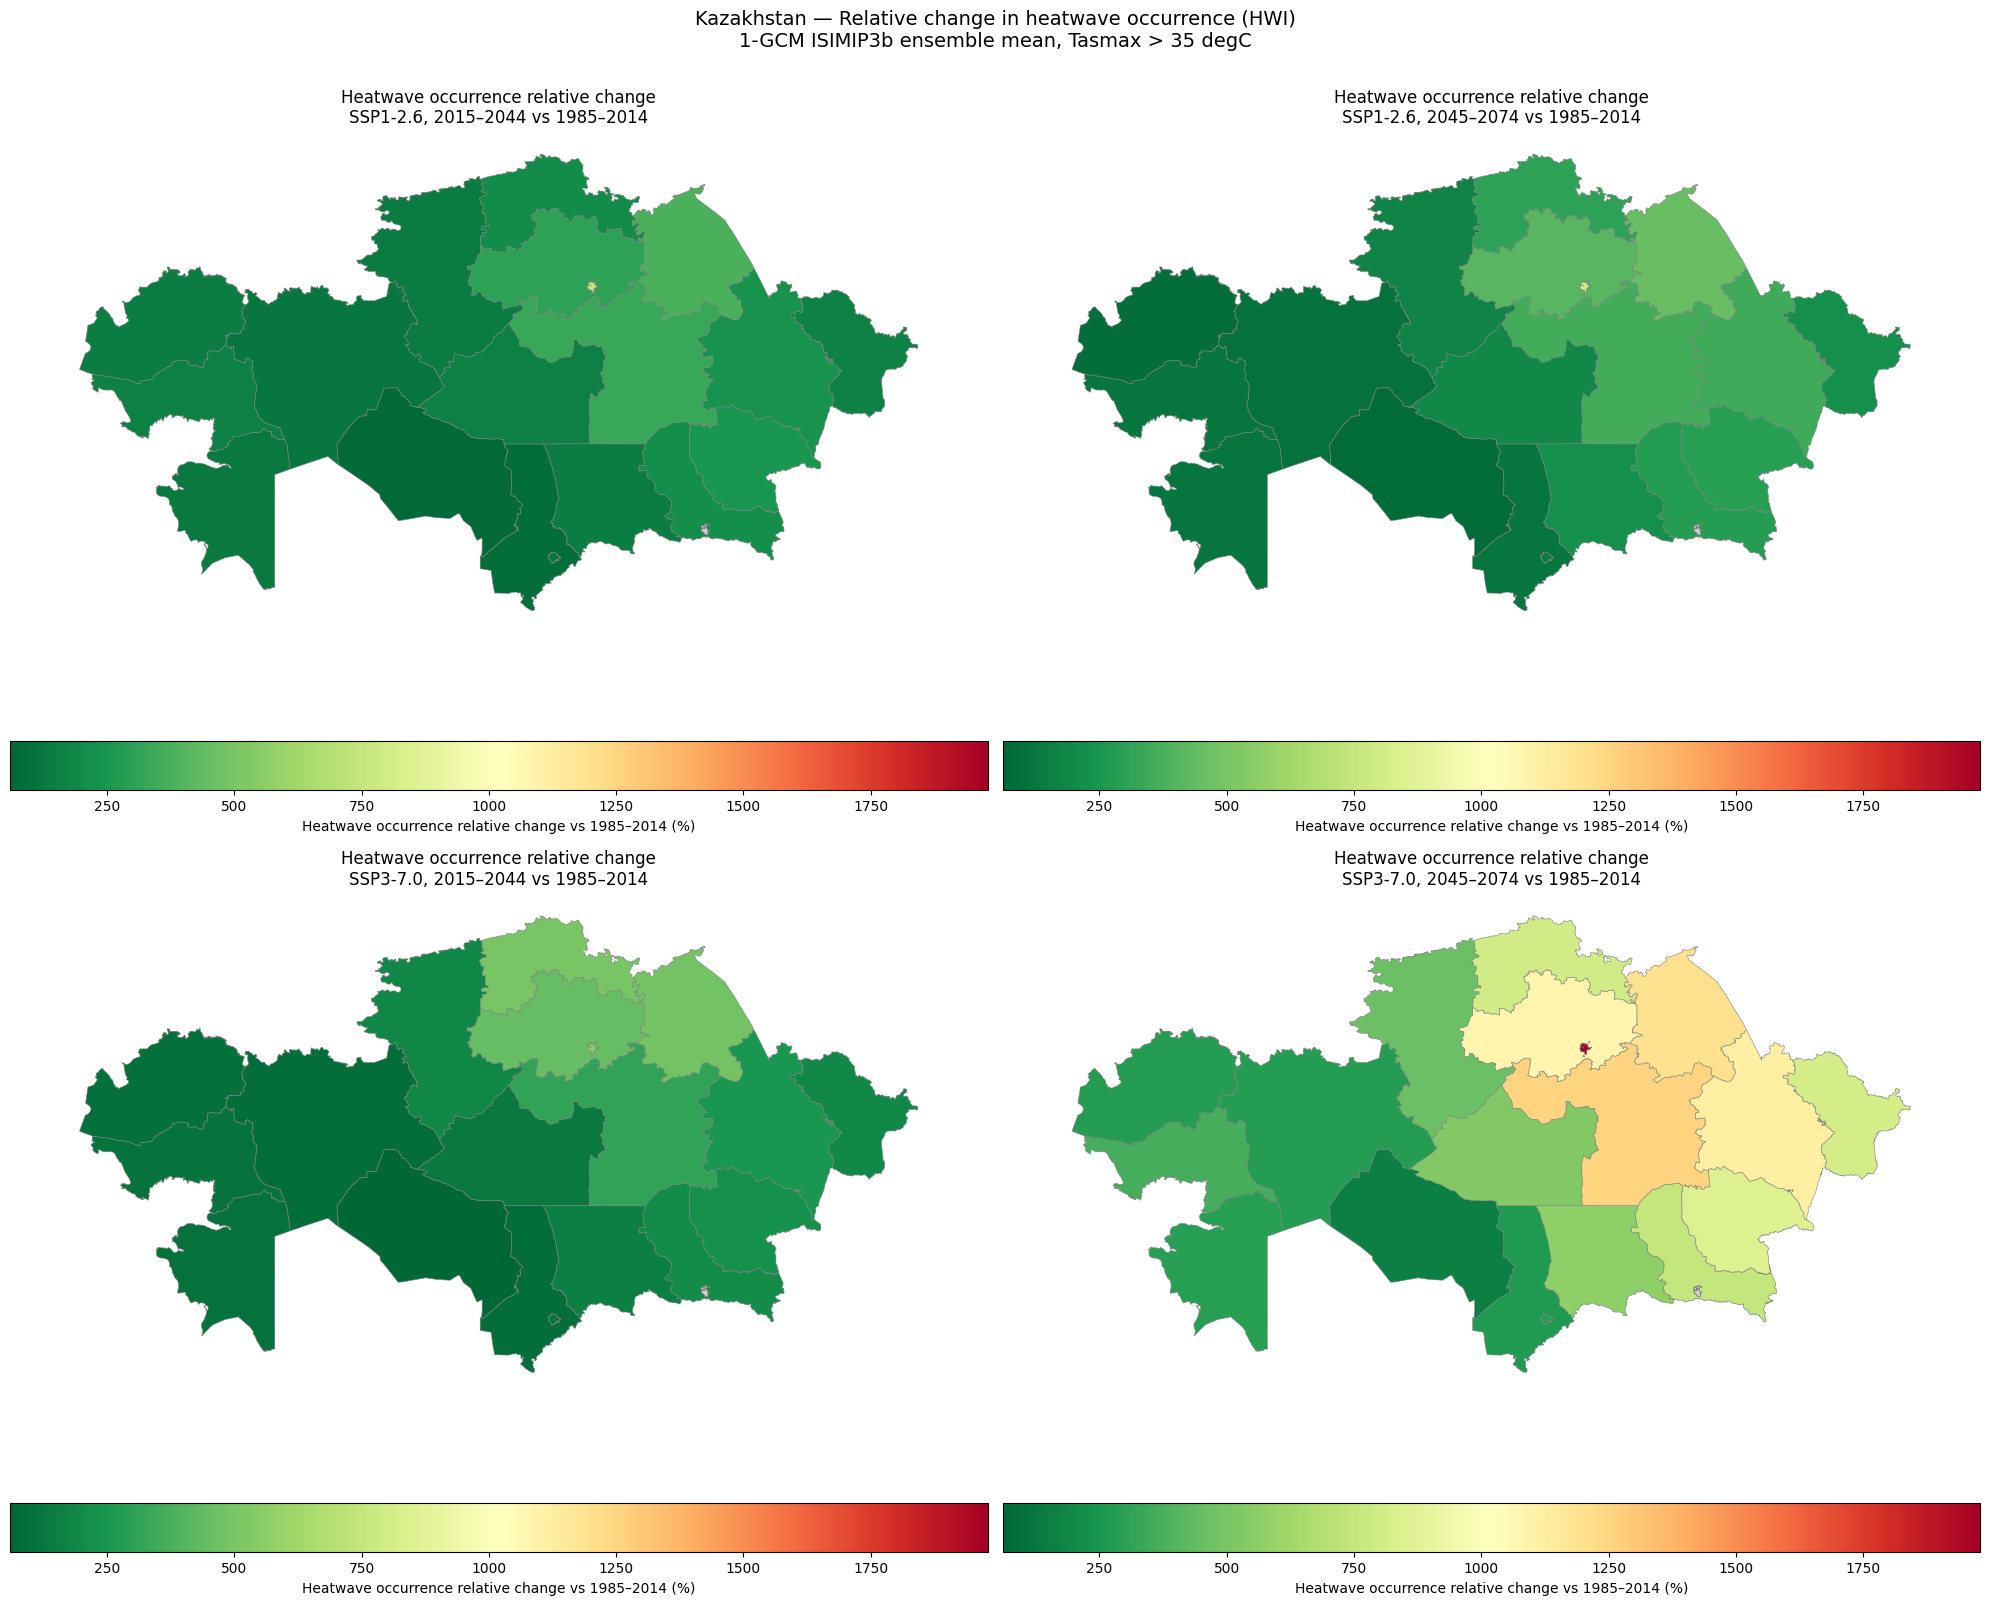

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()
cmap_rc = plt.get_cmap('RdYlGn_r')

for ax, (key, g), (_, scen, period) in zip(axes, hz_gdfs.items(), CHANGE_MAPS):
    g.plot(
        column='rc_mean', ax=ax, cmap=cmap_rc, legend=True,
        vmin=rc_min, vmax=rc_max,
        legend_kwds={
            'label': 'Heatwave occurrence relative change vs 1985–2014 (%)',
            'orientation': 'horizontal',
        },
        edgecolor='0.5', linewidth=0.4,
        missing_kwds={'color': 'lightgrey', 'label': 'No baseline HWI'},
    )
    ax.set_title(f'Heatwave occurrence relative change\n{scen}, {period} vs 1985–2014', size=12)
    ax.axis('off')

plt.suptitle(
    'Kazakhstan — Relative change in heatwave occurrence (HWI)\n'
    f'{len(MODEL_NAMES)}-GCM ISIMIP3b ensemble mean, Tasmax > {HWI_THRESH_TASMAX}',
    size=14, y=1.01,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'relative_change_heatwave.png', dpi=150, bbox_inches='tight')
plt.show()

### Plot — Reclassified hazard magnitude (1–10)


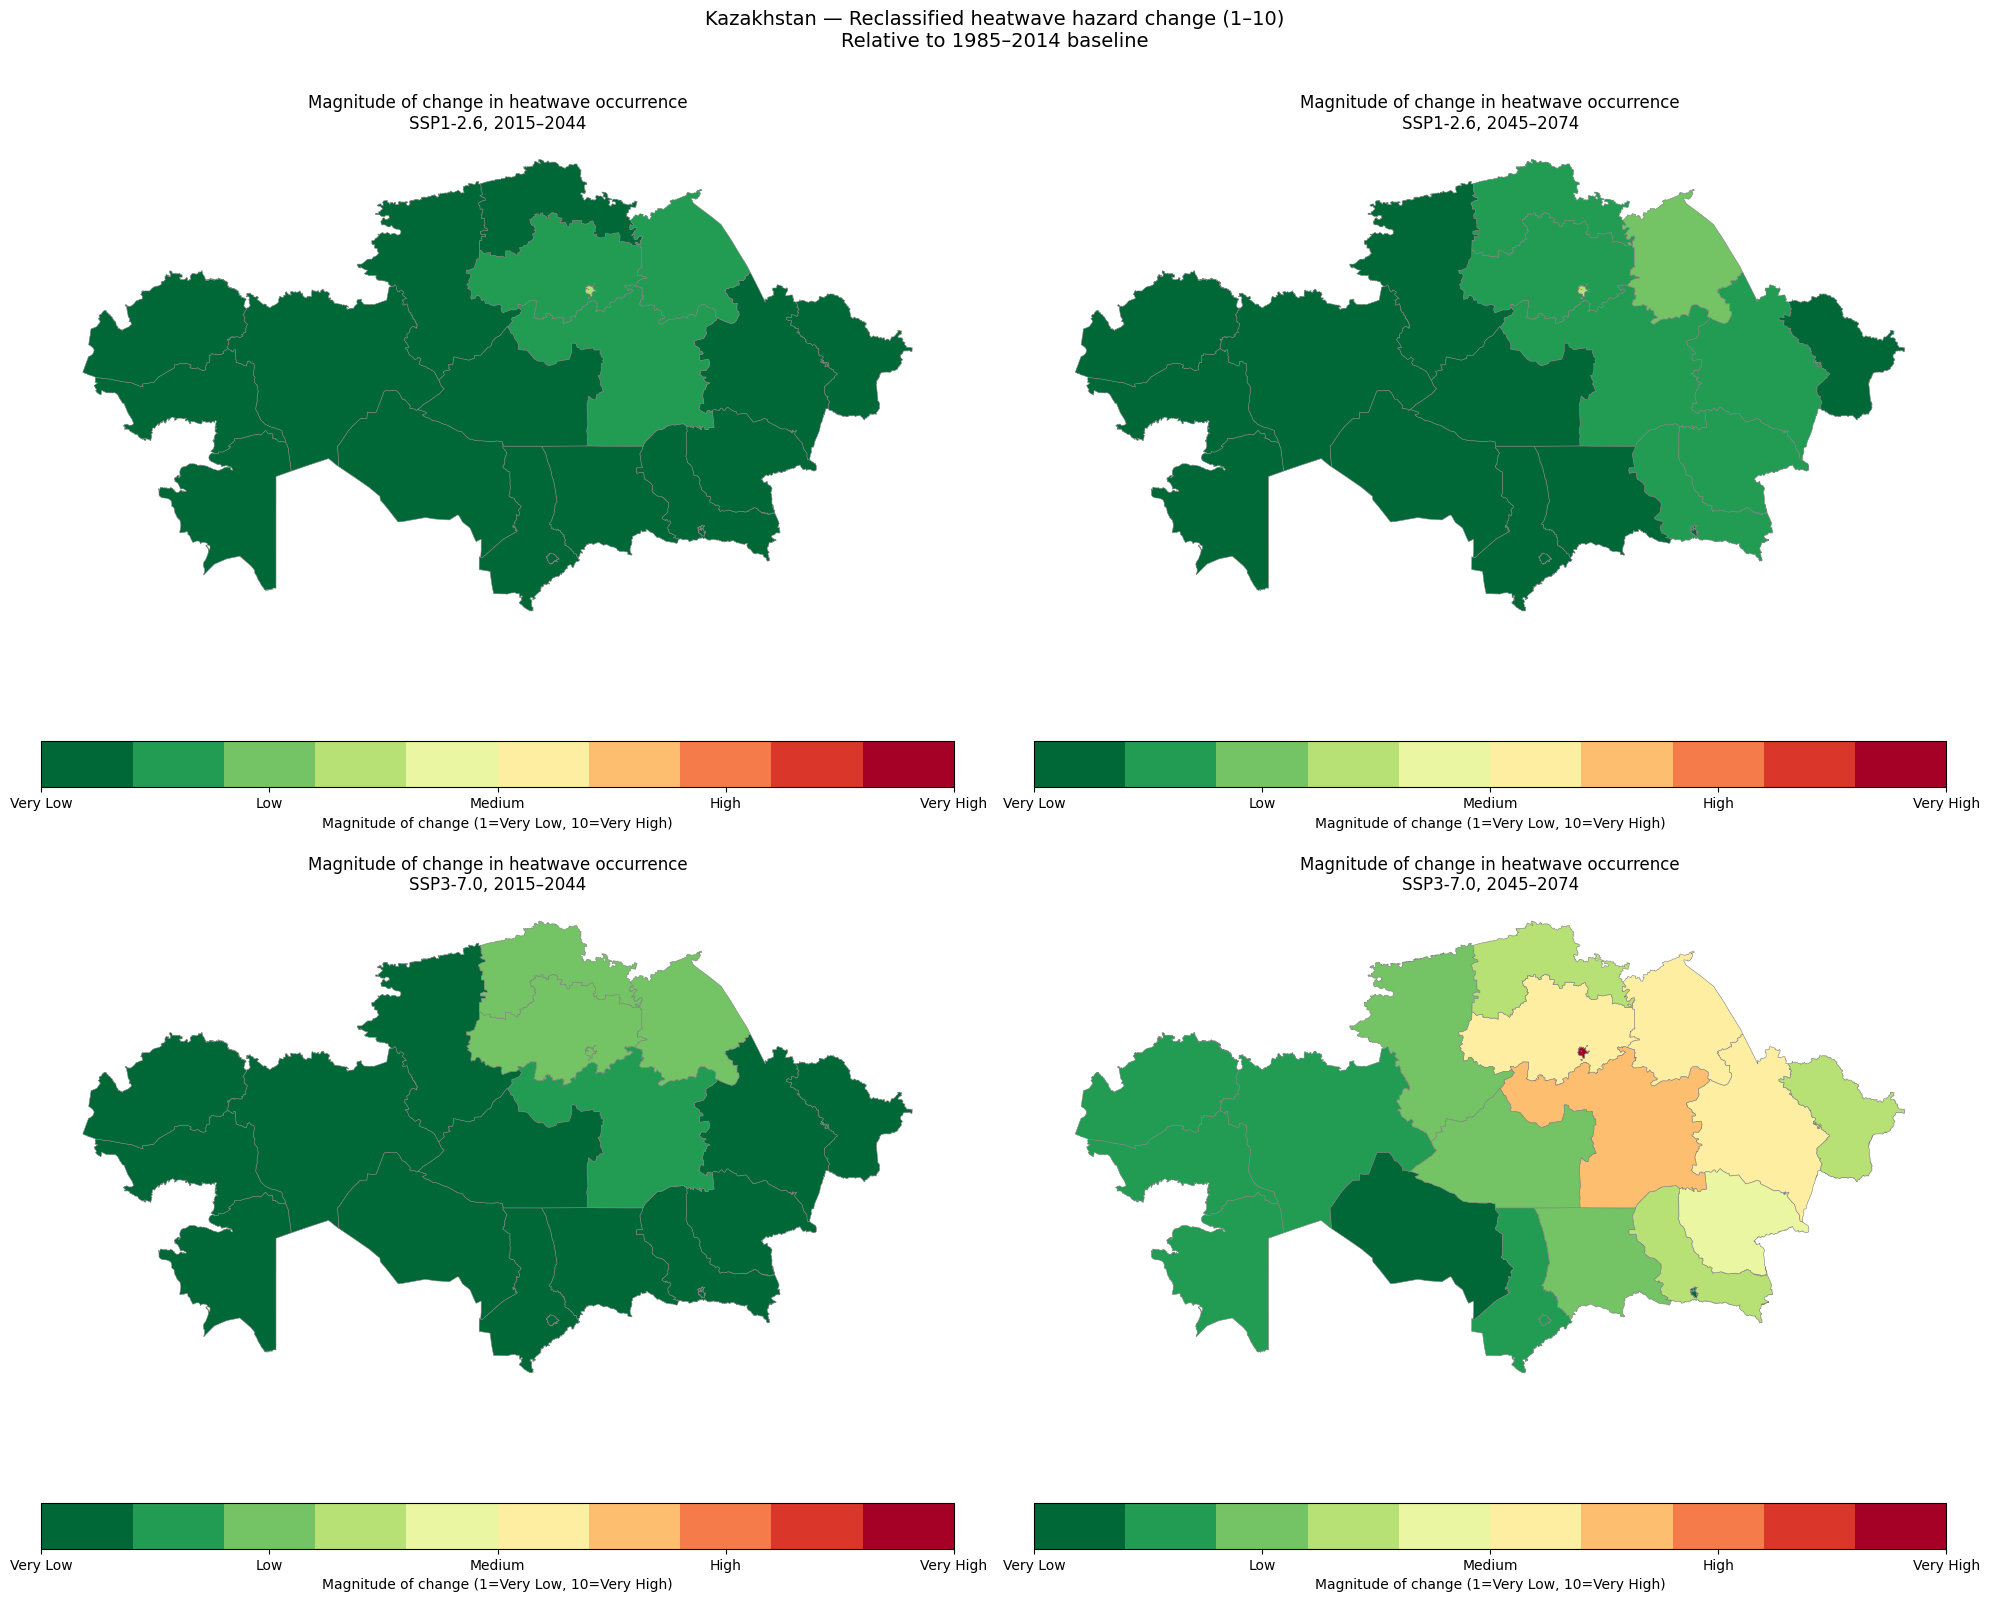

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()
cmap10 = plt.get_cmap('RdYlGn_r', 10)

for ax, (key, g), (_, scen, period) in zip(axes, hz_gdfs.items(), CHANGE_MAPS):
    g.plot(
        column='hz_class', ax=ax, cmap=cmap10, vmin=1, vmax=10,
        legend=True,
        legend_kwds={
            'label': 'Magnitude of change (1=Very Low, 10=Very High)',
            'orientation': 'horizontal',
            'ticks': [1, 3.25, 5.5, 7.75, 10],
        },
        edgecolor='0.5', linewidth=0.4,
        missing_kwds={'color': 'lightgrey'},
    )
    cbar = ax.get_figure().axes[-1]
    cbar.set_xticklabels(['Very Low', 'Low', 'Medium', 'High', 'Very High'])
    ax.set_title(f'Magnitude of change in heatwave occurrence\n{scen}, {period}', size=12)
    ax.axis('off')

plt.suptitle(
    'Kazakhstan — Reclassified heatwave hazard change (1–10)\nRelative to 1985–2014 baseline',
    size=14, y=1.01,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'hazard_classified.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Vulnerable Population Data (WorldPop)

### Manual download instructions — WorldPop Hub

1. Go to **https://hub.worldpop.org/geodata/listing?id=29**
2. Select **Kazakhstan**, year **2020**
3. Download (male `m` and female `f`, age groups 1, 65, 70, 75, 80):
   `kaz_f_1_2020.tif`, `kaz_m_1_2020.tif`,
   `kaz_f_65_2020.tif`, `kaz_m_65_2020.tif`,
   `kaz_f_70_2020.tif`, `kaz_m_70_2020.tif`,
   `kaz_f_75_2020.tif`, `kaz_m_75_2020.tif`,
   `kaz_f_80_2020.tif`, `kaz_m_80_2020.tif`
4. Place all `.tif` files in: `Heatwave_risk_projection_KZ/data/population/`

Full-country files are needed since this workflow covers all Kazakhstan oblasts.


In [17]:
pop_files = sorted(POP_DIR.glob('kaz_*.tif'))
print(f"Found {len(pop_files)} WorldPop file(s)")
if not pop_files:
    print("⚠ No WorldPop files found. Follow download instructions above.")
for f in pop_files:
    print(f"  {f.name}")

Found 1 WorldPop file(s)
  kaz_ppp_2020.tif


### Process population — sum vulnerable age groups, zonal stats per oblast


In [18]:
pop_sum_path = DATA_DIR / 'pop_sum_kaz.tif'

if pop_sum_path.exists():
    print(f"Cached: {pop_sum_path.name}")
else:
    pop = xr.open_mfdataset(
        [str(f) for f in pop_files],
        chunks='auto', concat_dim='band', combine='nested',
    )['band_data']
    pop = pop.rio.clip_box(
        minx=bbox[0], miny=bbox[1], maxx=bbox[2], maxy=bbox[3],
    )
    pop = pop.sum(dim='band', skipna=True, keep_attrs=True)
    pop.rio.to_raster(pop_sum_path)
    print(f"Saved: {pop_sum_path.name}")

pop_stats = rasterstats.zonal_stats(
    gdf, str(pop_sum_path),
    stats='mean', all_touched=True, nodata=np.nan,
)
gdf_pop = gdf.copy()
gdf_pop['pop_mean'] = [
    s['mean'] if s['mean'] is not None else np.nan for s in pop_stats
]

pop_min  = float(gdf_pop['pop_mean'].min())
pop_max  = float(gdf_pop['pop_mean'].max())
pop_bins = np.linspace(pop_min, pop_max, 11)

def classify_pop(val, bins):
    if np.isnan(val): return np.nan
    return max(1, min(10, int(np.digitize(val, bins, right=True))))

gdf_pop['pop_class'] = gdf_pop['pop_mean'].apply(lambda x: classify_pop(x, pop_bins))

gdf_pop[[OBLAST_FIELD, 'pop_mean', 'pop_class', 'geometry']].to_file(
    RESULTS_DIR / 'population_classified_oblasts.gpkg', driver='GPKG'
)
print(f"Population class range: {gdf_pop['pop_class'].min():.0f} – "
      f"{gdf_pop['pop_class'].max():.0f}")

Saved: pop_sum_kaz.tif
Population class range: 1 – 10


### Plot — Vulnerable population density by oblast


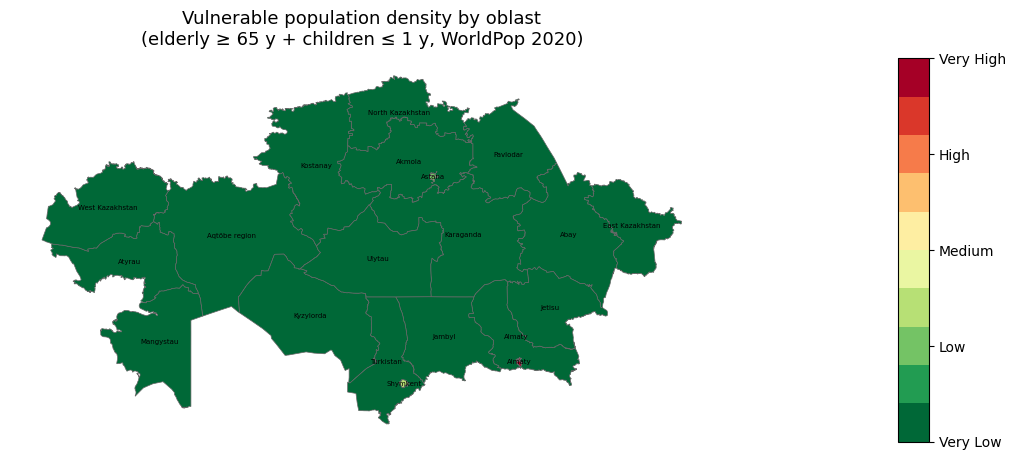

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))
cmap_pop = plt.get_cmap('RdYlGn_r', 10)
gdf_pop.plot(
    column='pop_class', ax=ax, cmap=cmap_pop, vmin=1, vmax=10,
    edgecolor='0.4', linewidth=0.5, legend=False,
)
sm = plt.cm.ScalarMappable(cmap=cmap_pop, norm=plt.Normalize(vmin=1, vmax=10))
sm._A = []
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='3%', pad=0.1)
cbar = fig.colorbar(sm, cax=cax, ticks=[1, 3.25, 5.5, 7.75, 10])
cbar.ax.set_yticklabels(['Very Low', 'Low', 'Medium', 'High', 'Very High'], size=10)

for _, row in gdf_pop.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(cx, cy, row[OBLAST_FIELD].replace(' Region', ''),
            fontsize=5, ha='center', va='center', color='black')

ax.set_title(
    'Vulnerable population density by oblast\n'
    '(elderly \u2265 65 y + children \u2264 1 y, WorldPop 2020)',
    size=13, pad=10,
)
ax.axis('off')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'population_classified.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Risk = Hazard Class + Population Class

Risk scale: 2 (Very Low) → 20 (Very High)

| Risk score | Interpretation |
|---|---|
| 2–5 | Very Low — little change in heatwave occurrence, few vulnerable people |
| 6–10 | Low |
| 11–14 | Medium |
| 15–18 | High |
| 19–20 | Very High — large increase in heatwaves AND high vulnerable population |


In [21]:
risk_gdfs = {}
for key, hz_g in hz_gdfs.items():
    risk_g = hz_g[[OBLAST_FIELD, 'hz_class', 'geometry']].copy()
    risk_g['pop_class'] = gdf_pop['pop_class'].values
    risk_g['risk']      = risk_g['hz_class'] + risk_g['pop_class']
    scen, period = key.split('_', 1)
    fname_safe = f"risk_{scen.replace('-','').replace('.','_')}_{period.replace('–','_')}.gpkg"
    risk_g.to_file(RESULTS_DIR / fname_safe, driver='GPKG')
    risk_gdfs[key] = risk_g

print("Risk layers saved.")

Risk layers saved.


## Step 9: Plot Risk Maps


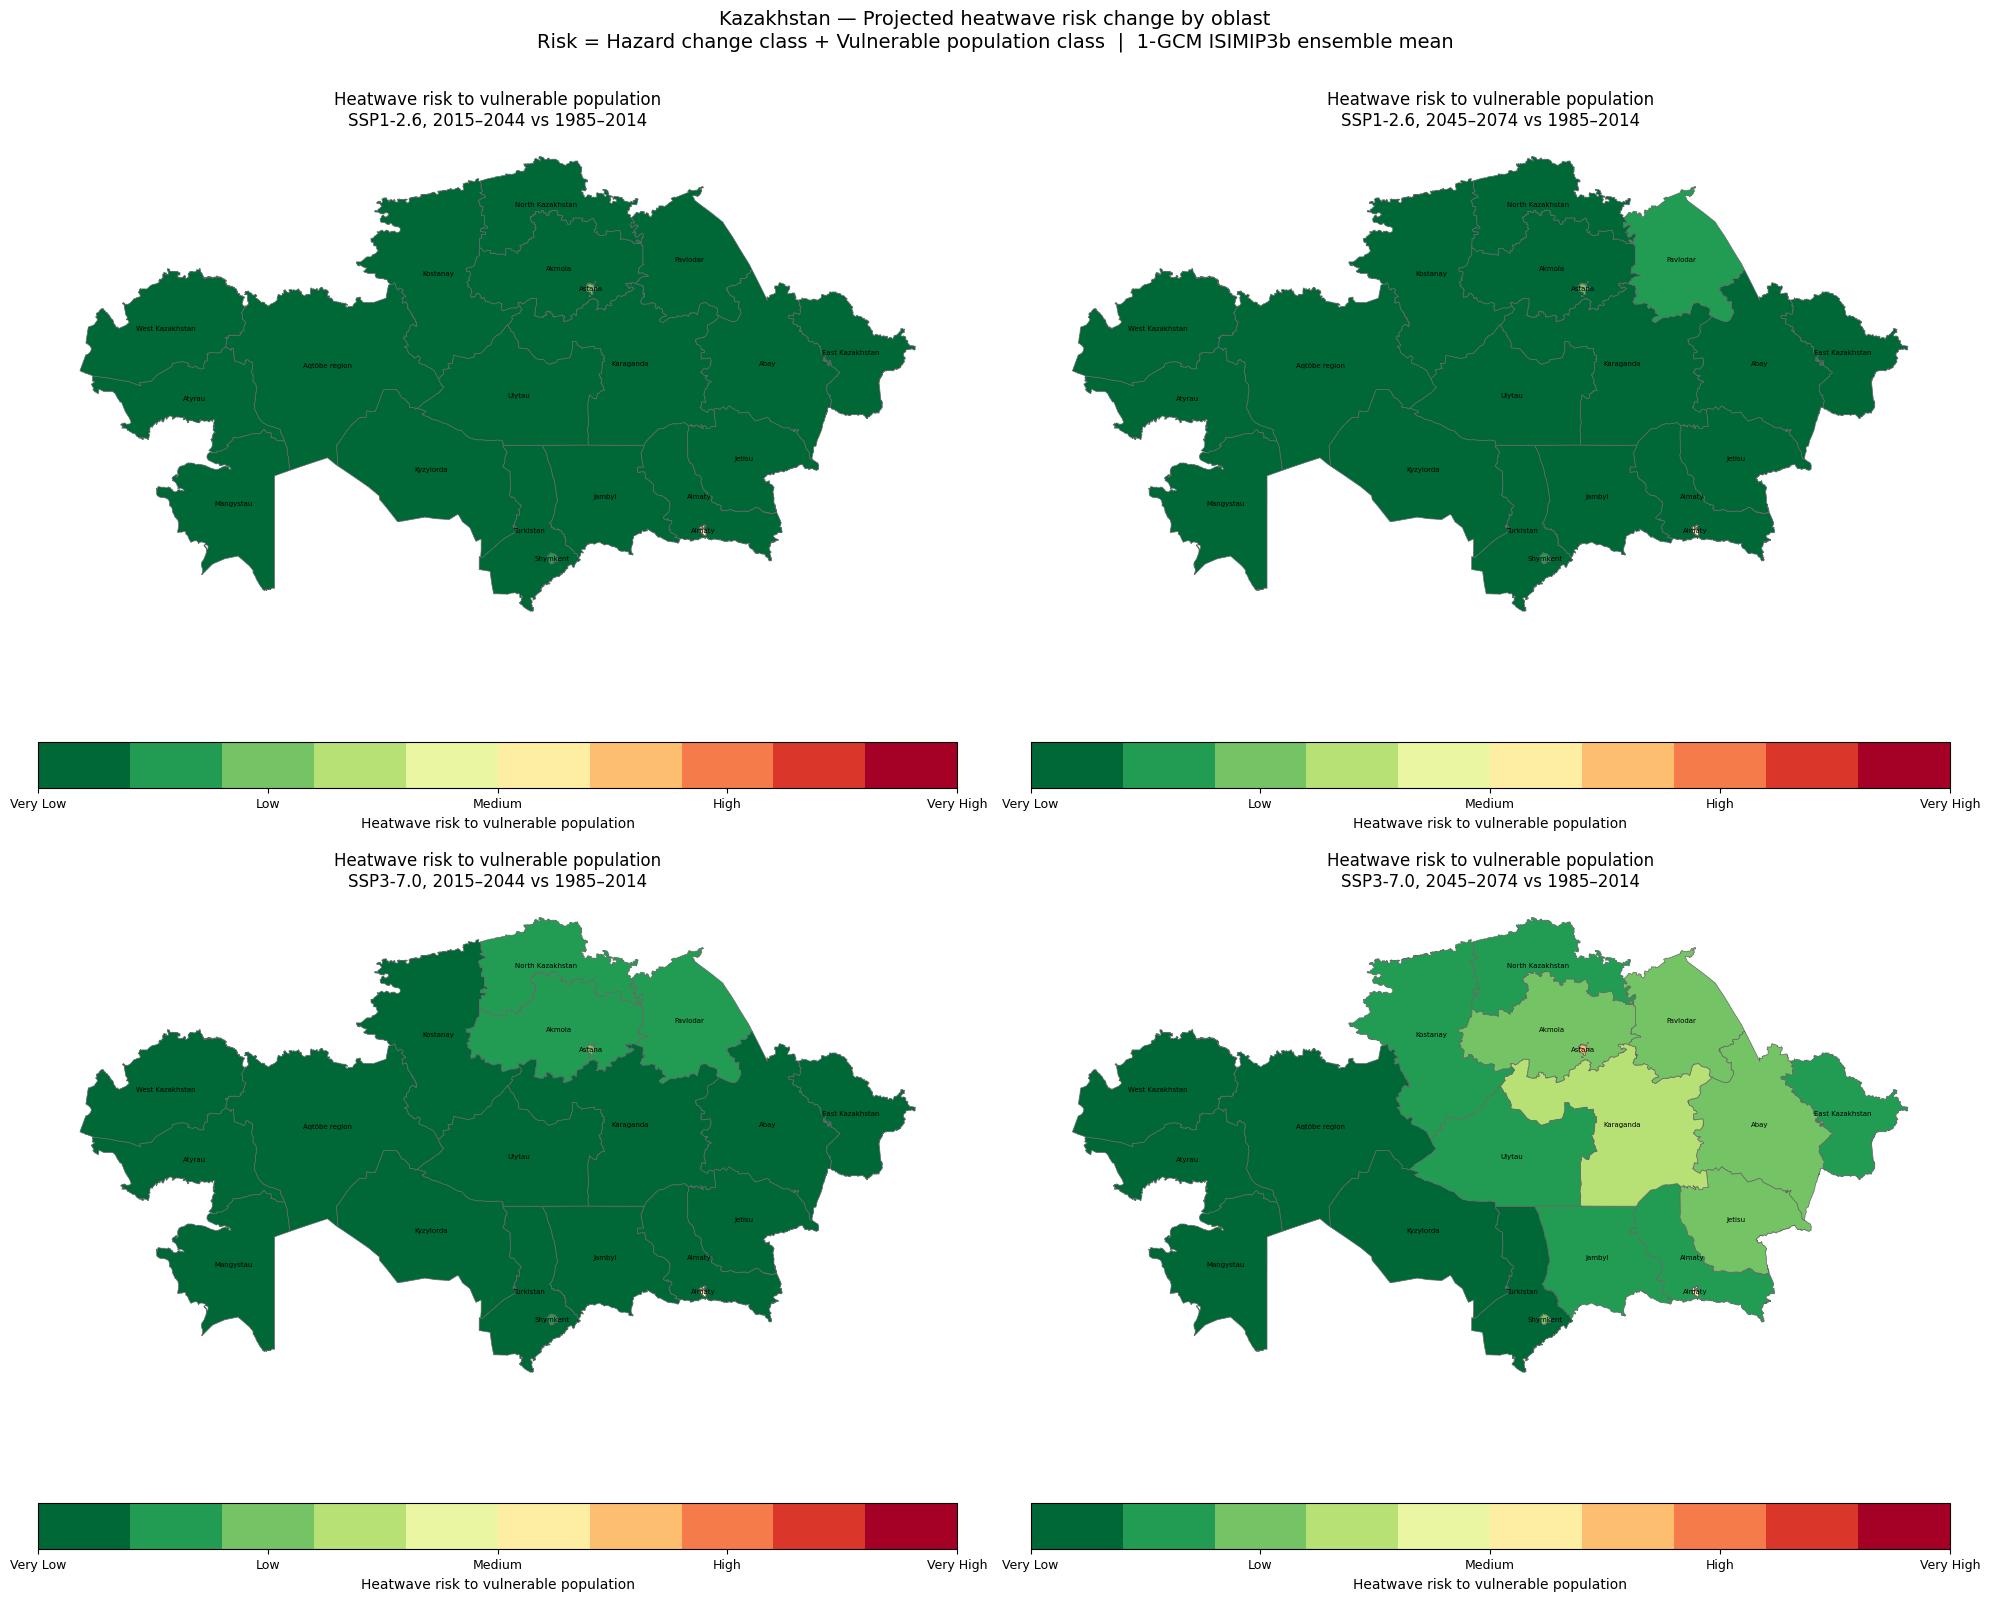

In [22]:
CLASS_TICKS  = [2, 6.5, 11, 15.5, 20]
CLASS_LABELS = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()
cmap_risk = plt.get_cmap('RdYlGn_r', 10)

for ax, (key, risk_g), (_, scen, period) in zip(axes, risk_gdfs.items(), CHANGE_MAPS):
    risk_g.plot(
        column='risk', ax=ax, cmap=cmap_risk, vmin=2, vmax=20,
        edgecolor='0.4', linewidth=0.5, legend=True,
        legend_kwds={
            'label': 'Heatwave risk to vulnerable population',
            'orientation': 'horizontal',
            'ticks': CLASS_TICKS,
        },
        missing_kwds={'color': 'lightgrey'},
    )
    cbar_ax = ax.get_figure().axes[-1]
    cbar_ax.set_xticklabels(CLASS_LABELS, fontsize=9)

    for _, row in risk_g.iterrows():
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.text(cx, cy, str(row[OBLAST_FIELD]).replace(' Region', ''),
                fontsize=5, ha='center', va='center', color='black')

    ax.set_title(
        f'Heatwave risk to vulnerable population\n{scen}, {period} vs 1985–2014',
        size=12,
    )
    ax.axis('off')

plt.suptitle(
    'Kazakhstan — Projected heatwave risk change by oblast\n'
    'Risk = Hazard change class + Vulnerable population class  |  '
    f'{len(MODEL_NAMES)}-GCM ISIMIP3b ensemble mean',
    size=14, y=1.01,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'heatwave_risk_projection.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions

The maps show which Kazakhstan oblasts face the greatest projected increase
in heatwave risk to vulnerable people (elderly ≥ 65 y and children ≤ 1 y)
under two climate scenarios.

### Key caveats

- **Risk reflects relative differences within Kazakhstan only.** A “Very High”
  rating means highest within Kazakhstan — not a global comparison.
- **0.5° grid resolution (~55 km).** Oblast-level zonal statistics smooth out
  local variation. Small oblasts (Astana, Almaty city) may be dominated by
  1–2 grid cells; treat their values with caution.
- **Zero historical HWI.** In northern oblasts where Tasmax rarely exceeds
  35 °C historically, the relative change metric is undefined (shown grey).
  Consider using absolute change (future − historical) for these oblasts.
- **WorldPop is modelled.** Based on 2020 census-derived models; local
  demographic data would reduce uncertainty.
- **Single threshold (35 °C).** Adjust `HWI_THRESH_TASMAX` in Step 0
  if a different threshold is preferred.

### To explore results further
All output GeoPackage files in `results/` can be opened in QGIS for
interactive exploration at oblast level.


## References

- Lange, S. (2019). ISIMIP3BASD. *Geosci. Model Dev.*, 12, 3055–3070.
- Bourgault et al. (2023). Xclim. *JOSS*, 8(85), 5415.
- WorldPop (2020). Age-structured population, Kazakhstan.
  https://hub.worldpop.org/geodata/listing?id=29
- ISIMIP3b protocol: https://www.isimip.org/protocol/3b/


## Authors

- Original CLIMAAX workflow: Martin Kuban, Milan Kalas, Milica Aleksic
  (KAJO services); review by Natalia Aleksandrova (Deltares)
